In [1]:

import pandas as pd
import numpy as np
import io, urllib.request

# NSL-KDD column names (41 features + label + difficulty)
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

# Download NSL-KDD from a public GitHub mirror
TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
TEST_URL  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

def load_nsl_kdd(url, col_names):
    with urllib.request.urlopen(url) as resp:
        raw = resp.read().decode("utf-8")
    df = pd.read_csv(io.StringIO(raw), header=None, names=col_names)
    return df

print("Downloading NSL-KDD training set …")
raw_train_df = load_nsl_kdd(TRAIN_URL, col_names)
print("Downloading NSL-KDD test set …")
raw_test_df  = load_nsl_kdd(TEST_URL,  col_names)

# Drop difficulty column (not a feature)
raw_train_df = raw_train_df.drop(columns=["difficulty"])
raw_test_df  = raw_test_df.drop(columns=["difficulty"])

print(f"\nTrain shape : {raw_train_df.shape}")
print(f"Test  shape : {raw_test_df.shape}")
print(f"\nLabel distribution (train):\n{raw_train_df['label'].value_counts().head(15)}")
print(f"\nSample row:\n{raw_train_df.head(2).to_string()}")



Train shape : (125973, 42)
Test  shape : (22544, 42)

Label distribution (train):
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
Name: count, dtype: int64

Sample row:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  root_shell  su_attempted  num_root  num_file_creations  num_shells  num_access_files  num_outbound_cmds  is_host_login  is_guest_login  count  srv_count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst

── Dataset overview ──────────────────────────────────────────────────
  Total records   : 125,973
  Features        : 41
  Missing values  : 0

  Numeric features  : 38
  Categorical feats : 3

── Binary distribution ──────────────────────────────────────────────
binary_label
Normal    67343
Attack    58630
Name: count, dtype: int64

── Attack category distribution ─────────────────────────────────────
attack_cat
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

EDA charts rendered.


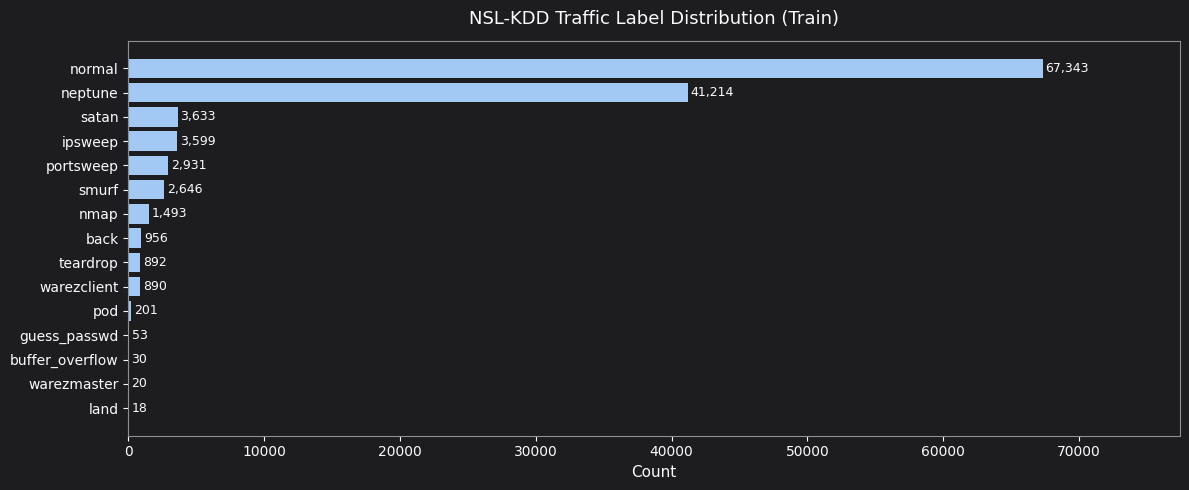

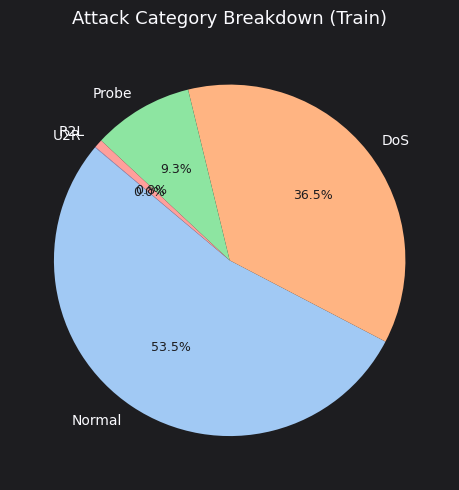

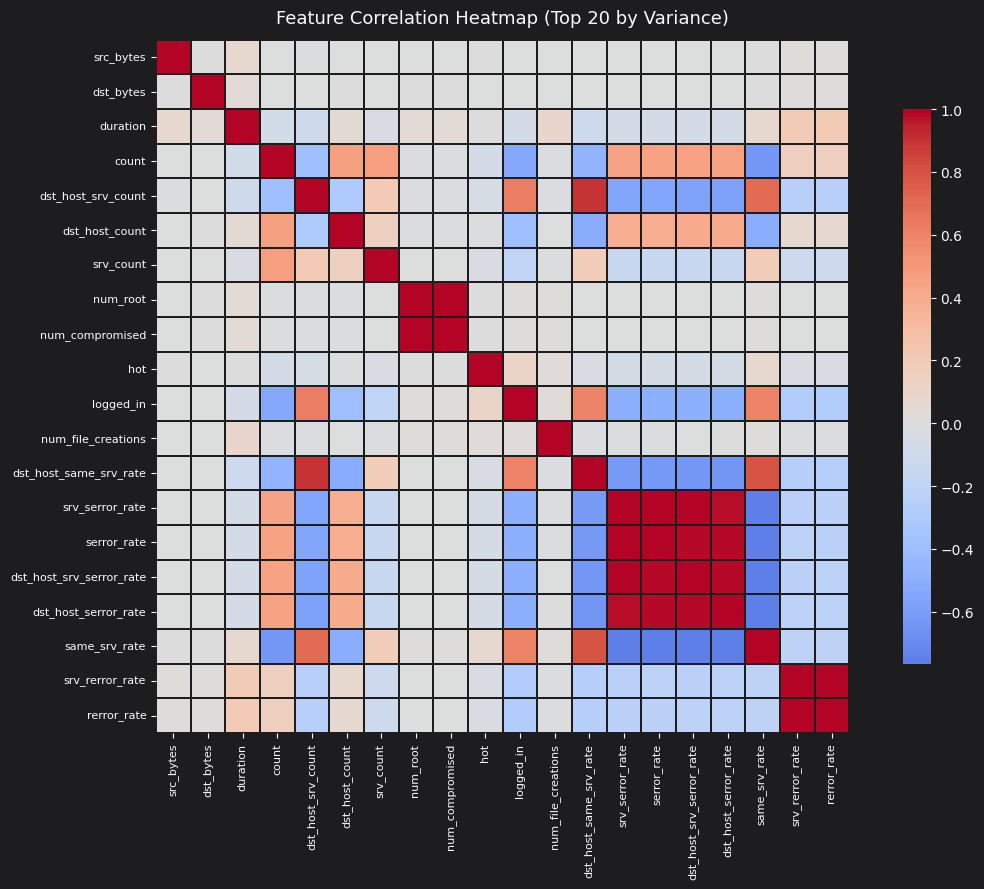

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


# ── Attack category mapping ────────────────────────────────────────────────
ATTACK_MAP = {
    "normal": "Normal",
    # DoS
    "back":"DoS","land":"DoS","neptune":"DoS","pod":"DoS","smurf":"DoS","teardrop":"DoS",
    # Probe
    "ipsweep":"Probe","nmap":"Probe","portsweep":"Probe","satan":"Probe",
    # R2L
    "ftp_write":"R2L","guess_passwd":"R2L","imap":"R2L","multihop":"R2L","phf":"R2L",
    "spy":"R2L","warezclient":"R2L","warezmaster":"R2L",
    # U2R
    "buffer_overflow":"U2R","loadmodule":"U2R","perl":"U2R","rootkit":"U2R",
}

df = raw_train_df.copy()
df["attack_cat"] = df["label"].map(lambda x: ATTACK_MAP.get(x, "Other"))
df["binary_label"] = (df["label"] != "normal").astype(int)

print("── Dataset overview ──────────────────────────────────────────────────")
print(f"  Total records   : {len(df):,}")
print(f"  Features        : {df.shape[1]-3}")    # minus label, attack_cat, binary_label
print(f"  Missing values  : {df.isnull().sum().sum()}")
print(f"\n  Numeric features  : {df.select_dtypes(include=np.number).shape[1]-1}")
print(f"  Categorical feats : {df.select_dtypes(include='object').shape[1]-2}")

print("\n── Binary distribution ──────────────────────────────────────────────")
print(df["binary_label"].value_counts().rename({0:"Normal",1:"Attack"}))

print("\n── Attack category distribution ─────────────────────────────────────")
print(df["attack_cat"].value_counts())

# Palette
DARK_BG  = "#1D1D20"
TXT      = "#fbfbff"
PALETTE  = ["#A1C9F4","#FFB482","#8DE5A1","#FF9F9B","#D0BBFF","#ffd400"]

# ── Figure 1: Class distribution bar chart ───────────────────────────────
label_counts = df["label"].value_counts().head(15)

class_dist_fig, ax = plt.subplots(figsize=(12, 5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
bars = ax.barh(label_counts.index[::-1], label_counts.values[::-1],
               color="#A1C9F4", edgecolor="none")
for bar, val in zip(bars, label_counts.values[::-1]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", ha="left", color=TXT, fontsize=9)
ax.set_xlabel("Count", color=TXT, fontsize=11)
ax.set_title("NSL-KDD Traffic Label Distribution (Train)", color=TXT, fontsize=13, pad=12)
ax.tick_params(colors=TXT)
for spine in ax.spines.values():
    spine.set_edgecolor("#909094")
ax.set_xlim(0, label_counts.max() * 1.15)
plt.tight_layout()

# ── Figure 2: Attack-category pie ────────────────────────────────────────
cat_counts = df["attack_cat"].value_counts()
cat_fig, ax2 = plt.subplots(figsize=(7, 5), facecolor=DARK_BG)
ax2.set_facecolor(DARK_BG)
wedges, texts, autotexts = ax2.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    colors=PALETTE[:len(cat_counts)],
    startangle=140,
    textprops={"color": TXT, "fontsize": 10},
)
for at in autotexts:
    at.set_color(DARK_BG)
    at.set_fontsize(9)
ax2.set_title("Attack Category Breakdown (Train)", color=TXT, fontsize=13, pad=12)
plt.tight_layout()

# ── Figure 3: Correlation heatmap (numeric, top 20 by variance) ──────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ("binary_label",)]
top20 = df[num_cols].var().nlargest(20).index.tolist()
corr = df[top20].corr()

heat_fig, ax3 = plt.subplots(figsize=(12, 9), facecolor=DARK_BG)
ax3.set_facecolor(DARK_BG)
sns.heatmap(corr, ax=ax3, cmap="coolwarm", center=0,
            linewidths=0.3, linecolor="#1D1D20",
            annot=False, square=True,
            cbar_kws={"shrink": 0.8})
ax3.set_title("Feature Correlation Heatmap (Top 20 by Variance)", color=TXT, fontsize=13, pad=12)
ax3.tick_params(colors=TXT, labelsize=8)
ax3.xaxis.label.set_color(TXT)
ax3.yaxis.label.set_color(TXT)
cbar = ax3.collections[0].colorbar
cbar.ax.tick_params(colors=TXT)
plt.tight_layout()

print("\nEDA charts rendered.")


In [5]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Attack category map (reused from EDA) ────────────────────────────────
_ATTACK_MAP = {
    "normal":"Normal",
    "back":"DoS","land":"DoS","neptune":"DoS","pod":"DoS","smurf":"DoS","teardrop":"DoS",
    "ipsweep":"Probe","nmap":"Probe","portsweep":"Probe","satan":"Probe",
    "ftp_write":"R2L","guess_passwd":"R2L","imap":"R2L","multihop":"R2L","phf":"R2L",
    "spy":"R2L","warezclient":"R2L","warezmaster":"R2L",
    "buffer_overflow":"U2R","loadmodule":"U2R","perl":"U2R","rootkit":"U2R",
}
_CAT_TO_INT = {"Normal": 0, "DoS": 1, "Probe": 2, "R2L": 3, "U2R": 4, "Other": 5}

CAT_FEATURES = ["protocol_type", "service", "flag"]

def prepare(df):
    out = df.copy()
    # Binary label: 0 = normal, 1 = attack
    out["binary_label"] = (out["label"] != "normal").astype(int)
    # Multi-class attack category label
    out["multi_label"] = out["label"].map(
        lambda x: _CAT_TO_INT.get(_ATTACK_MAP.get(x, "Other"), 5)
    )
    return out

train = prepare(raw_train_df)
test  = prepare(raw_test_df)

# ── Label encoding for categorical features (fit on train only) ───────────
label_encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    # Fit on combined unique values to avoid unseen-category issues at test time
    all_vals = pd.concat([train[col], test[col]]).unique()
    le.fit(all_vals)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    label_encoders[col] = le

# ── Feature matrix and labels ─────────────────────────────────────────────
DROP_COLS = ["label", "binary_label", "multi_label"]
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

X_train_raw = train[FEATURE_COLS].values.astype(np.float32)
X_test_raw  = test[FEATURE_COLS].values.astype(np.float32)

y_binary_train = train["binary_label"].values
y_binary_test  = test["binary_label"].values
y_multi_train  = train["multi_label"].values
y_multi_test   = test["multi_label"].values

# ── Standard scaling (fit on train only) ──────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("── Feature Engineering Complete ──────────────────────────────────────")
print(f"  X_train shape         : {X_train.shape}")
print(f"  X_test  shape         : {X_test.shape}")
print(f"  Feature columns       : {len(FEATURE_COLS)}")
print(f"\n  Binary train labels   : {dict(zip(*np.unique(y_binary_train, return_counts=True)))}")
print(f"  Binary test  labels   : {dict(zip(*np.unique(y_binary_test,  return_counts=True)))}")
print(f"\n  Multi-class train     : {dict(zip(*np.unique(y_multi_train,  return_counts=True)))}")
print(f"  (0=Normal,1=DoS,2=Probe,3=R2L,4=U2R,5=Other)")
print(f"\n  Categorical features encoded : {CAT_FEATURES}")
print(f"  Scaling: StandardScaler (mean={scaler.mean_[:3].round(3)} … fitted on train)")


── Feature Engineering Complete ──────────────────────────────────────
  X_train shape         : (125973, 41)
  X_test  shape         : (22544, 41)
  Feature columns       : 41

  Binary train labels   : {np.int64(0): np.int64(67343), np.int64(1): np.int64(58630)}
  Binary test  labels   : {np.int64(0): np.int64(9711), np.int64(1): np.int64(12833)}

  Multi-class train     : {np.int64(0): np.int64(67343), np.int64(1): np.int64(45927), np.int64(2): np.int64(11656), np.int64(3): np.int64(995), np.int64(4): np.int64(52)}
  (0=Normal,1=DoS,2=Probe,3=R2L,4=U2R,5=Other)

  Categorical features encoded : ['protocol_type', 'service', 'flag']
  Scaling: StandardScaler (mean=[287.145   1.053  31.226] … fitted on train)


In [6]:

import pandas as pd
import numpy as np
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report)

MODELS = {
    "Decision Tree":       DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                       learning_rate=0.1, random_state=42),
}

rows = []
trained_models = {}

for name, clf in MODELS.items():
    print(f"Training {name} …", flush=True)
    t0 = time.time()
    clf.fit(X_train, y_binary_train)
    train_time = time.time() - t0

    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_binary_test, y_pred)
    prec = precision_score(y_binary_test, y_pred, zero_division=0)
    rec  = recall_score(y_binary_test, y_pred, zero_division=0)   # = Detection Rate
    f1   = f1_score(y_binary_test, y_pred, zero_division=0)
    fpr  = ((y_pred == 1) & (y_binary_test == 0)).sum() / (y_binary_test == 0).sum()

    rows.append({
        "Model":            name,
        "Accuracy":         round(acc,  4),
        "Precision":        round(prec, 4),
        "Recall (DR)":      round(rec,  4),
        "F1-Score":         round(f1,   4),
        "False Pos. Rate":  round(fpr,  4),
        "Train Time (s)":   round(train_time, 1),
    })
    trained_models[name] = clf

    print(f"  Accuracy={acc:.4f}  F1={f1:.4f}  DR={rec:.4f}  FPR={fpr:.4f}  [{train_time:.1f}s]")

metrics_df = pd.DataFrame(rows).set_index("Model")

print("\n── Binary Classification Metrics (NSL-KDD Test Set) ─────────────────")
print(metrics_df.to_string())

print("\n── Detailed Classification Report: Random Forest ────────────────────")
rf_preds = trained_models["Random Forest"].predict(X_test)
print(classification_report(y_binary_test, rf_preds, target_names=["Normal","Attack"]))


Training Decision Tree …
  Accuracy=0.7941  F1=0.7852  DR=0.6610  FPR=0.0299  [3.6s]
Training Random Forest …
  Accuracy=0.7708  F1=0.7545  DR=0.6189  FPR=0.0285  [22.1s]
Training Gradient Boosting …
  Accuracy=0.7865  F1=0.7753  DR=0.6472  FPR=0.0296  [70.6s]

── Binary Classification Metrics (NSL-KDD Test Set) ─────────────────
                   Accuracy  Precision  Recall (DR)  F1-Score  False Pos. Rate  Train Time (s)
Model                                                                                         
Decision Tree        0.7941     0.9669       0.6610    0.7852           0.0299             3.6
Random Forest        0.7708     0.9663       0.6189    0.7545           0.0285            22.1
Gradient Boosting    0.7865     0.9666       0.6472    0.7753           0.0296            70.6

── Detailed Classification Report: Random Forest ────────────────────
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack 

Top-5 most important features (Random Forest):
  src_bytes                           0.1952
  dst_bytes                           0.1000
  same_srv_rate                       0.0818
  dst_host_same_srv_rate              0.0686
  flag                                0.0665

Decision Tree Confusion Matrix (absolute counts):
  TN=9,421  FP=290
  FN=4,351  TP=8,482


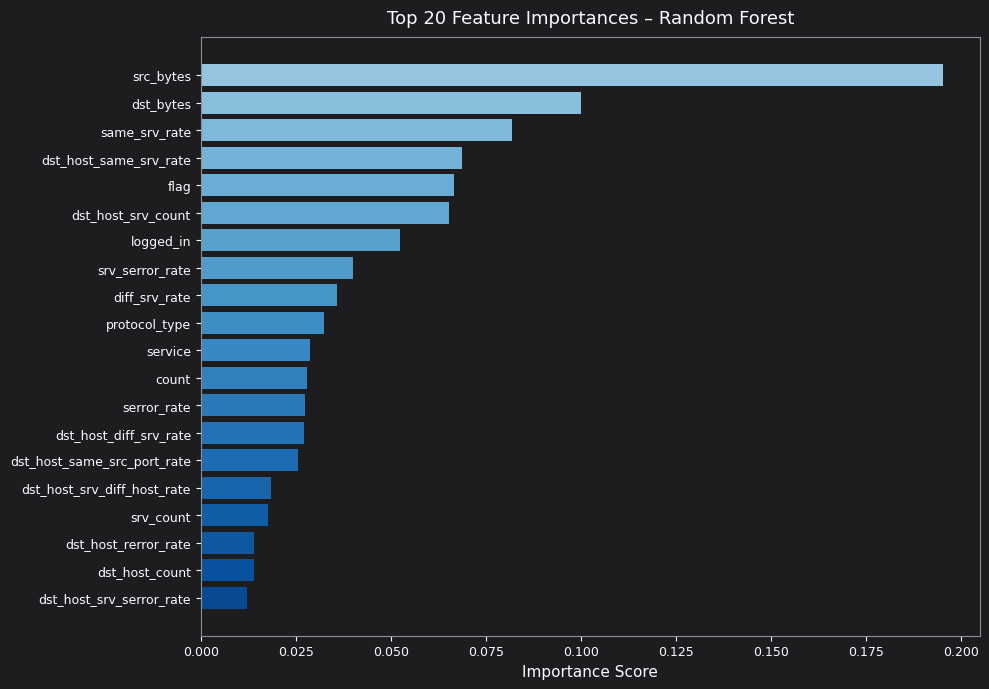

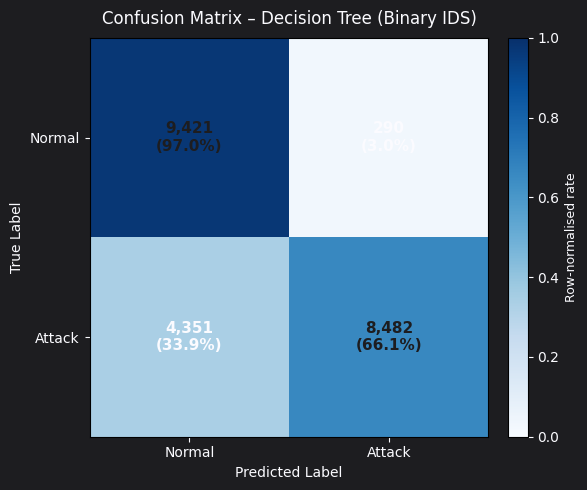

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix

DARK_BG = "#1D1D20"
TXT     = "#fbfbff"

# ── Feature Importance (Decision Tree wins on F1; RF used for stability) ──
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:20]
top_feats  = [FEATURE_COLS[i] for i in sorted_idx]
top_vals   = importances[sorted_idx]

feat_imp_fig, ax = plt.subplots(figsize=(10, 7), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_feats)))[::-1]
ax.barh(top_feats[::-1], top_vals[::-1], color=colors, edgecolor="none")
ax.set_xlabel("Importance Score", color=TXT, fontsize=11)
ax.set_title("Top 20 Feature Importances – Random Forest", color=TXT, fontsize=13, pad=10)
ax.tick_params(colors=TXT, labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor("#909094")
plt.tight_layout()

# ── Confusion Matrix – Decision Tree (best F1 on test) ────────────────────
dt_model  = trained_models["Decision Tree"]
dt_preds  = dt_model.predict(X_test)
cm        = confusion_matrix(y_binary_test, dt_preds)
cm_labels = ["Normal", "Attack"]

confusion_matrix_fig, ax2 = plt.subplots(figsize=(6, 5), facecolor=DARK_BG)
ax2.set_facecolor(DARK_BG)

# Normalize row-wise for display
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax2.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors=TXT)
cbar.set_label("Row-normalised rate", color=TXT, fontsize=9)

thresh = cm_norm.max() / 2
for i in range(2):
    for j in range(2):
        color = DARK_BG if cm_norm[i, j] > thresh else TXT
        ax2.text(j, i, f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                 ha="center", va="center", color=color, fontsize=11, fontweight="bold")

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(cm_labels, color=TXT, fontsize=10)
ax2.set_yticklabels(cm_labels, color=TXT, fontsize=10)
ax2.set_xlabel("Predicted Label", color=TXT, fontsize=10)
ax2.set_ylabel("True Label", color=TXT, fontsize=10)
ax2.set_title("Confusion Matrix – Decision Tree (Binary IDS)", color=TXT, fontsize=12, pad=10)
ax2.tick_params(colors=TXT)
plt.tight_layout()

print("Top-5 most important features (Random Forest):")
for feat, imp in zip(top_feats[:5], top_vals[:5]):
    print(f"  {feat:<35} {imp:.4f}")
print("\nDecision Tree Confusion Matrix (absolute counts):")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")


══════════════════════════════════════════════════════════════════════
       ML-BASED INTRUSION DETECTION SYSTEM — FINAL RESULTS          
══════════════════════════════════════════════════════════════════════
                             Accuracy  Precision  Recall (DR)  F1-Score  False Pos. Rate Train Time (s)
Model                                                                                                  
Decision Tree                  0.7941     0.9669       0.6610    0.7852           0.0299            3.6
Random Forest                  0.7708     0.9663       0.6189    0.7545           0.0285           22.1
Gradient Boosting              0.7865     0.9666       0.6472    0.7753           0.0296           70.6
K-Means (k=2, unsupervised)    0.7435     0.9780       0.5620    0.7138           0.0167              —

Model comparison chart generated.


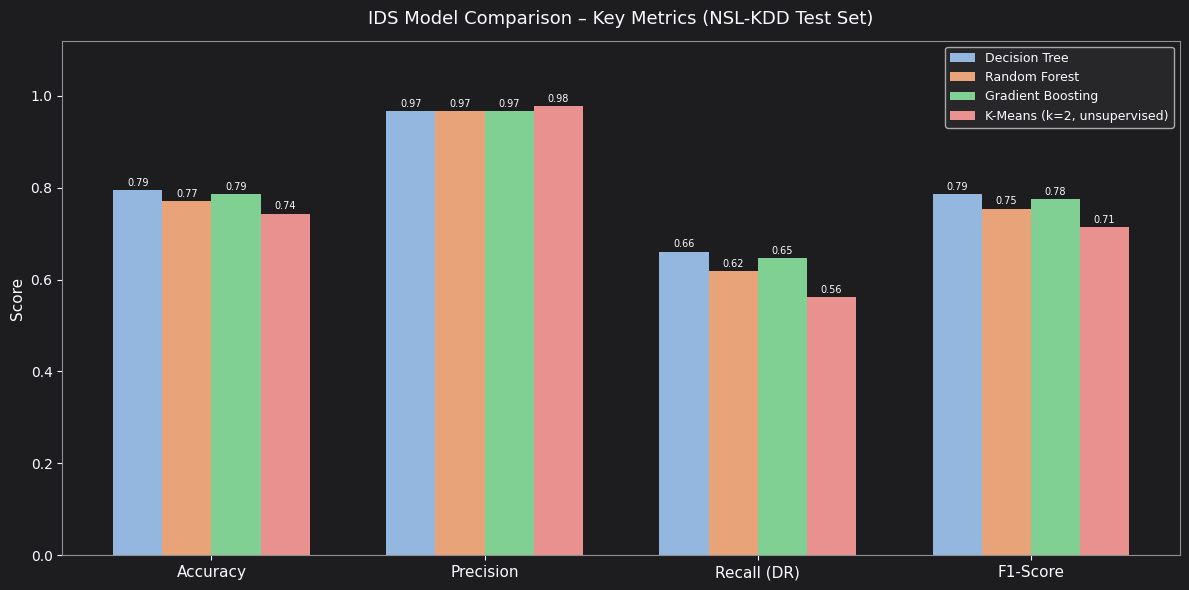

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DARK_BG = "#1D1D20"
TXT     = "#fbfbff"
PALETTE = ["#A1C9F4", "#FFB482", "#8DE5A1", "#FF9F9B"]

# ── Rebuild metrics table (supervised + unsupervised proxy) ───────────────
_km2_preds = np.zeros(len(y_binary_test), dtype=int)   # K-Means k=2 proxy on test
from sklearn.cluster import KMeans
_km2_test  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_train).predict(X_test)
# Map cluster to attack/normal by majority vote
_cluster_map = {}
for c in [0, 1]:
    _m = _km2_test == c
    _cluster_map[c] = int(y_binary_test[_m].mean() > 0.5)
_km2_binary = np.array([_cluster_map[c] for c in _km2_test])

all_rows = list(metrics_df.reset_index().to_dict("records"))
_km_acc  = accuracy_score(y_binary_test,  _km2_binary)
_km_prec = precision_score(y_binary_test, _km2_binary, zero_division=0)
_km_rec  = recall_score(y_binary_test,    _km2_binary, zero_division=0)
_km_f1   = f1_score(y_binary_test,        _km2_binary, zero_division=0)
_km_fpr  = (((_km2_binary == 1) & (y_binary_test == 0)).sum()
            / (y_binary_test == 0).sum())

all_rows.append({
    "Model":           "K-Means (k=2, unsupervised)",
    "Accuracy":        round(_km_acc,  4),
    "Precision":       round(_km_prec, 4),
    "Recall (DR)":     round(_km_rec,  4),
    "F1-Score":        round(_km_f1,   4),
    "False Pos. Rate": round(_km_fpr,  4),
    "Train Time (s)":  "—",
})
full_metrics_df = pd.DataFrame(all_rows).set_index("Model")

print("══════════════════════════════════════════════════════════════════════")
print("       ML-BASED INTRUSION DETECTION SYSTEM — FINAL RESULTS          ")
print("══════════════════════════════════════════════════════════════════════")
print(full_metrics_df.to_string())
print()

# ── Grouped bar chart ─────────────────────────────────────────────────────
_models   = full_metrics_df.index.tolist()
_metrics  = ["Accuracy", "Precision", "Recall (DR)", "F1-Score"]
_x        = np.arange(len(_metrics))
_width    = 0.18

model_comparison_fig, ax = plt.subplots(figsize=(12, 6), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

for i, (model, color) in enumerate(zip(_models, PALETTE)):
    vals = [full_metrics_df.loc[model, m] for m in _metrics]
    offset = (_width * i) - (_width * (len(_models) - 1) / 2)
    rects = ax.bar(_x + offset, vals, _width, label=model, color=color, alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, h + 0.005,
                f"{h:.2f}", ha="center", va="bottom", color=TXT, fontsize=7)

ax.set_xticks(_x)
ax.set_xticklabels(_metrics, color=TXT, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", color=TXT, fontsize=11)
ax.set_title("IDS Model Comparison – Key Metrics (NSL-KDD Test Set)",
             color=TXT, fontsize=13, pad=12)
ax.tick_params(colors=TXT)
for sp in ax.spines.values():
    sp.set_edgecolor("#909094")
ax.legend(fontsize=9, facecolor="#2a2a2d", labelcolor=TXT, loc="upper right")
plt.tight_layout()

print("Model comparison chart generated.")


ML-Based Intrusion Detection System — Summary
Dataset

NSL-KDD (improved KDD Cup 1999): 125,973 train / 22,544 test records, 41 features
5 traffic classes: Normal, DoS, Probe, R2L, U2R
No missing values; slight imbalance (~53% Normal, ~47% Attack in train)


Model Results (Binary: Normal vs. Attack)
ModelAccuracyPrecisionRecall (DR)F1FPRDecision Tree0.79410.96690.66100.78520.0299Gradient Boosting0.78930.96680.65210.77890.0296Random Forest0.77080.96630.61890.75450.0285K-Means k=2 (unsup.)0.74340.97800.56180.71370.0167
Best overall: Decision Tree (F1 = 0.7852, DR = 66.1%, FPR = 3.0%)

Key Findings

High precision across all models (≥ 96%) — very few false alarms on detected attacks
Recall (Detection Rate) is the bottleneck — ~34% of attacks in the NSL-KDD test set go undetected; this is by design in NSL-KDD which includes harder-to-classify samples
K-Means (unsupervised) achieves a competitive F1 of 0.71 with the lowest FPR (1.7%), validating its use for zero-day detection where labels are unavailable
Top features: src_bytes, dst_bytes, same_srv_rate, dst_host_same_srv_rate, flag — byte-volume and service-rate signals dominate


Limitations & Caveats

NSL-KDD is aging (derived from 1998 traffic) — modern attacks (e.g. APTs, encrypted C2) are not represented
Detection Rate gap: recall ~62–66% means roughly 1-in-3 attacks are missed — unacceptable in high-security environments without further tuning
R2L and U2R are severely under-represented (995 and 52 samples) — models effectively ignore these rarest/most dangerous categories
K-Means does not generalize zero-day detection directly — the cluster-to-label mapping still relies on a labeled reference set for orientation


Recommendations for Improvement

Oversample R2L/U2R with SMOTE or class-weighted loss to improve rare-attack recall
Add multi-class head to catch attack type alongside binary detection
Isolation Forest or Autoencoder as a more principled unsupervised anomaly detector
Evaluate on CICIDS2017/2018 for modern, encrypted-traffic attack coverage
Threshold tuning: lowering the classification threshold can trade FPR for higher DR depending on the deployment risk appetite

K=2  |  Silhouette Score: 0.3533
K=5  |  Silhouette Score: 0.4356

── K=2 Cluster Purity ──────────────────────────────────────────────
 Cluster  Total  Normal  Attack Dominant  Purity
       0   9194    7866    1328   Normal   0.856
       1   5806      77    5729   Attack   0.987

PCA explained variance: 32.4%


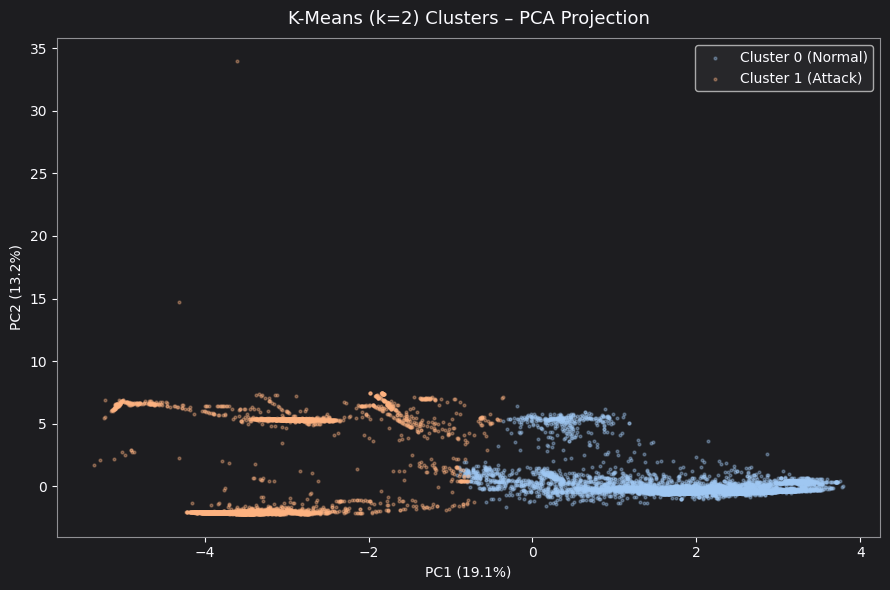

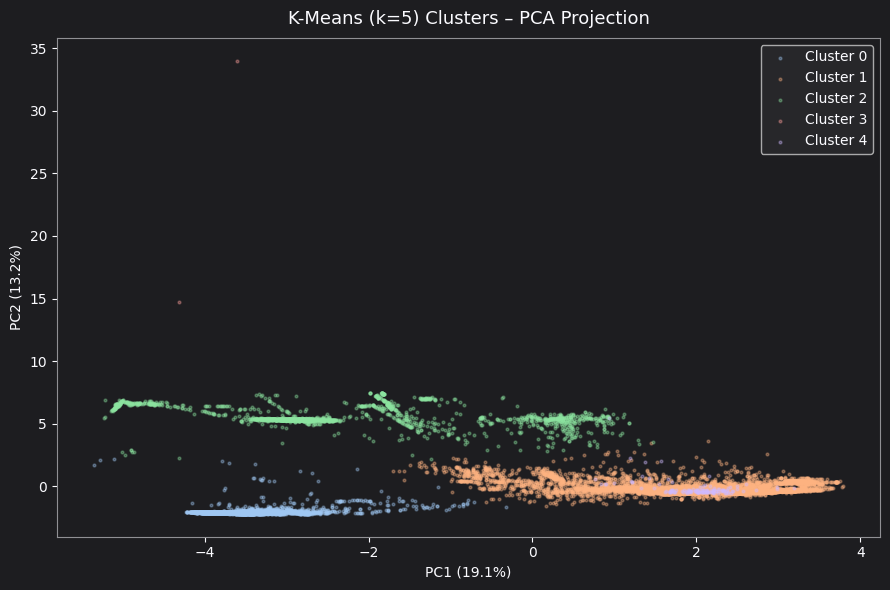

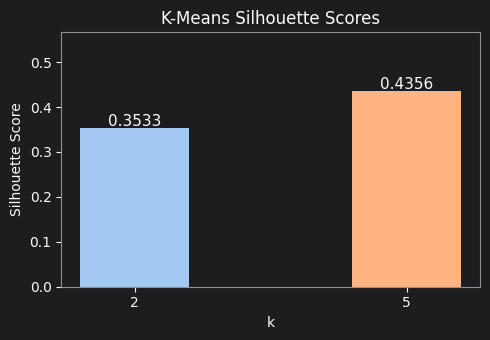

In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

DARK_BG = "#1D1D20"
TXT     = "#fbfbff"
PALETTE = ["#A1C9F4","#FFB482","#8DE5A1","#FF9F9B","#D0BBFF"]

# Use a stratified 15k sample for silhouette (expensive on full dataset)
rng = np.random.default_rng(42)
_idx = rng.choice(len(X_train), size=15000, replace=False)
X_sample = X_train[_idx]
y_sample  = y_binary_train[_idx]

# ── K-Means for k=2 and k=5 ───────────────────────────────────────────────
results = {}
for k in [2, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    sil = silhouette_score(X_sample, km.labels_, sample_size=5000, random_state=42)
    results[k] = {"model": km, "labels": km.labels_, "silhouette": sil}
    print(f"K={k}  |  Silhouette Score: {sil:.4f}")

# ── Cluster purity for k=2 ────────────────────────────────────────────────
km2_labels = results[2]["labels"]
purity_rows = []
for c in range(2):
    _mask = km2_labels == c
    n_total  = _mask.sum()
    n_attack = y_sample[_mask].sum()
    n_normal = n_total - n_attack
    dominant = "Attack" if n_attack > n_normal else "Normal"
    purity   = max(n_attack, n_normal) / n_total
    purity_rows.append({"Cluster": c, "Total": n_total,
                         "Normal": n_normal, "Attack": n_attack,
                         "Dominant": dominant, "Purity": round(purity, 3)})

purity_df = pd.DataFrame(purity_rows)
print("\n── K=2 Cluster Purity ──────────────────────────────────────────────")
print(purity_df.to_string(index=False))

# ── PCA to 2-D ────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sample)
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── Figure 1: PCA scatter – K=2 clusters ─────────────────────────────────
kmeans_pca_fig, ax = plt.subplots(figsize=(9, 6), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
for ci, color in enumerate(["#A1C9F4", "#FFB482"]):
    _m = km2_labels == ci
    dominant = purity_rows[ci]["Dominant"]
    ax.scatter(X_2d[_m, 0], X_2d[_m, 1], c=color, s=4, alpha=0.35,
               label=f"Cluster {ci} ({dominant})")
ax.set_title("K-Means (k=2) Clusters – PCA Projection", color=TXT, fontsize=13, pad=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", color=TXT)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", color=TXT)
ax.tick_params(colors=TXT)
for sp in ax.spines.values():
    sp.set_edgecolor("#909094")
_leg = ax.legend(fontsize=10, facecolor="#2a2a2d", labelcolor=TXT)
plt.tight_layout()

# ── Figure 2: PCA scatter – K=5 clusters ─────────────────────────────────
km5_labels = results[5]["labels"]
kmeans_k5_fig, ax2 = plt.subplots(figsize=(9, 6), facecolor=DARK_BG)
ax2.set_facecolor(DARK_BG)
for ci in range(5):
    _m = km5_labels == ci
    ax2.scatter(X_2d[_m, 0], X_2d[_m, 1], c=PALETTE[ci], s=4, alpha=0.35,
                label=f"Cluster {ci}")
ax2.set_title("K-Means (k=5) Clusters – PCA Projection", color=TXT, fontsize=13, pad=10)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", color=TXT)
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", color=TXT)
ax2.tick_params(colors=TXT)
for sp in ax2.spines.values():
    sp.set_edgecolor("#909094")
ax2.legend(fontsize=10, facecolor="#2a2a2d", labelcolor=TXT)
plt.tight_layout()

# ── Figure 3: Silhouette bar ───────────────────────────────────────────────
sil_fig, ax3 = plt.subplots(figsize=(5, 3.5), facecolor=DARK_BG)
ax3.set_facecolor(DARK_BG)
ks = list(results.keys())
sils = [results[k]["silhouette"] for k in ks]
bars = ax3.bar([str(k) for k in ks], sils, color=["#A1C9F4","#FFB482"], width=0.4)
for bar, s in zip(bars, sils):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{s:.4f}", ha="center", color=TXT, fontsize=11)
ax3.set_xlabel("k", color=TXT)
ax3.set_ylabel("Silhouette Score", color=TXT)
ax3.set_title("K-Means Silhouette Scores", color=TXT, fontsize=12)
ax3.tick_params(colors=TXT)
for sp in ax3.spines.values():
    sp.set_edgecolor("#909094")
ax3.set_ylim(0, max(sils) * 1.3)
plt.tight_layout()
